# Email Campaign A/B Test: Measuring Incremental Customer Spend

# 1. Data Loading

We first load the raw CSV, set up project paths, and import the libraries used in this project.

In [ ]:
from pathlib import Path
from scipy import stats
from scipy.stats import norm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'hillstrom_email_marketing.csv'

In [2]:
df_raw = pd.read_csv(RAW_DATA_PATH)

print(f'Rows: {df_raw.shape[0]:,}')
print(f'Columns: {df_raw.shape[1]:,}')

df_raw.head()

Rows: 64,000
Columns: 12


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


The raw dataset has 64,000 customer rows and 12 columns. It includes pre-campaign customer attributes, treatment assignment, and post-campaign outcomes for visit, conversion, and spend.

# 2. Experiment and Hypothesis Setup

**Treatment 1:** Mens Email, where the customer received a promotional email featuring mens merchandise.<br>
**Treatment 2:** Womens Email, where the customer received a promotional email featuring womens merchandise.<br>
**Control:** No Email, where the customer did not receive a promotional email.

All groups were randmoly chosen, and the outcome window is two weeks after the email campaign.

***Primary Hypothesis:*** Receiving a promotional email increases customer spend within two weeks compared with receiving no email.
- **Null hypothesis:** Average spend per customer is the same for email recipients and no-email customers.
- **Alternative hypothesis:** Average spend per customer is higher for email recipients than no-email customers.

***Success Metrics***:
- **Spend per Customer**: Revenue impact per randomized customer, directly related to revenue impact across all assigned customers, including cusomters who did not purchase.
- Total Spend: Total revenue by assigned group, business-friendly but not primary since group sizes are not exactly identical.

***Guradrail Metrics***:
- Conversion Rate: Percentage of assigned customers who purchased, email should not increase spend while reducing purchase likelihood.
- Spend per Buyer: Average spend among customers who purchased, checks whether revenue is supported by order quality.

***Tracking Metrics***:
- Visit Rate: Percentage of assigned customers who visited the website, explains whether email brought customers back to the site.
- Incremental spend per customer: Treatment spend per customer minus control spend per customer, shows the estimated business lift versus no email.

# 3. Exploratory Data Analysis

This section confirms missing values, data types, treatment labels, treatment group sizes, and outcome consistency.
The goal is to show that the experiment data is reasonable enough to analyze.

In [5]:
data_quality_summary = pd.DataFrame({
    'column': df_raw.columns,
    'dtype': [str(dtype) for dtype in df_raw.dtypes],
    'missing_values': df_raw.isna().sum().values,
    'unique_values': [df_raw[column].nunique() for column in df_raw.columns]
})

print('Missing values in dataset:', int(df_raw.isna().sum().sum()))
data_quality_summary

Missing values in dataset: 0


,column,dtype,missing_values,unique_values
0,recency,int64,0,12
1,history_segment,str,0,7
2,history,float64,0,34833
3,mens,int64,0,2
4,womens,int64,0,2
5,zip_code,str,0,3
6,newbie,int64,0,2
7,channel,str,0,3
8,segment,str,0,3
9,visit,int64,0,2


The dataset has no missing values. The fields are simple and readable: numeric customer attributes, categorical profile fields, treatment assignment, and three outcome columns.

In [6]:
treatment_counts = (
    df_raw['segment']
    .value_counts()
    .rename_axis('segment')
    .reset_index(name='customers')
)

treatment_counts['share_of_customers'] = treatment_counts['customers'] / len(df_raw)

treatment_counts

,segment,customers,share_of_customers
0,Womens E-Mail,21387,0.334172
1,Mens E-Mail,21307,0.332922
2,No E-Mail,21306,0.332906


Just as the data source description that customers were randomly split across each treatment group, the treatment groups are very balanced, with about one-third of customers assigned to each group.

In [8]:
df_clean = df_raw.copy()

# Keep the original source value and create a cleaned display version for reporting.
df_clean['zip_code_original'] = df_clean['zip_code']
df_clean['zip_code_clean'] = df_clean['zip_code'].replace({'Surburban': 'Suburban'})

df_clean.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,zip_code_original,zip_code_clean
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0,Surburban,Suburban
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,Rural,Rural
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0,Surburban,Suburban
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,Rural,Rural
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0,Urban,Urban


The only change from the raw data is updating the spelling 'Surburban' to 'Suburban' in `zip_code_original` -> `zip_code_clean`.

In [11]:
balance_columns = ['recency', 'history', 'mens', 'womens', 'newbie']

balance_means = df_clean.groupby('segment')[balance_columns].mean().T

balance_means.round(3)

segment,Mens E-Mail,No E-Mail,Womens E-Mail
recency,5.774,5.750,5.768
history,242.836,240.883,242.537
mens,0.551,0.553,0.549
womens,0.551,0.548,0.550
newbie,0.502,0.502,0.503


Here, we compare the listed pre-campaign customer attributes across the treatment groups to check for unusual differences. They seem to be very simlar across treatmentgroups, which suggests that they are comparable before the email campaign.

In [10]:
channel_balance = pd.crosstab(
    df_clean['segment'],
    df_clean['channel'],
    normalize='index'
).mul(100).round(2)

zip_balance = pd.crosstab(
    df_clean['segment'],
    df_clean['zip_code_clean'],
    normalize='index'
).mul(100).round(2)

print('Channel distribution by treatment group (%):')
display(channel_balance)

print('Zip code distribution by treatment group (%):')
display(zip_balance)

Channel distribution by treatment group (%):


channel,Multichannel,Phone,Web
segment,,,
Mens E-Mail,12.09,43.37,44.54
No E-Mail,12.23,43.78,43.99
Womens E-Mail,12.06,44.20,43.74


Zip code distribution by treatment group (%):


zip_code_clean,Rural,Suburban,Urban
segment,,,
Mens E-Mail,15.22,44.59,40.19
No E-Mail,14.73,45.18,40.09
Womens E-Mail,14.87,45.12,40.01


Another balance check on the treatment groups on channel and zipcode distributions. It doesn't show any obvious randomization issues, which suggests it's reasonable to compare treatment groups against the control group.

In [26]:
df_clean.groupby('segment').agg(customers=('segment','size'),visits=('visit', 'sum')).reindex(group_order).reset_index()

,segment,customers,visits
0,No E-Mail,21306,2262
1,Mens E-Mail,21307,3894
2,Womens E-Mail,21387,3238


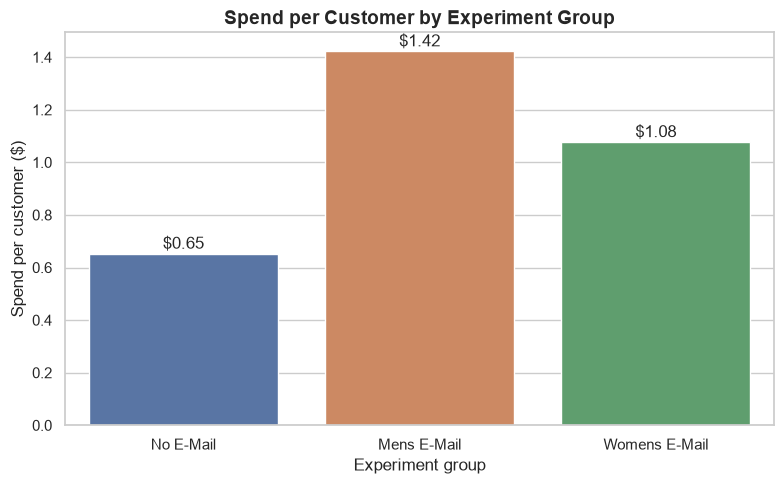

,segment,customers,visits,conversions,total_spend,visit_rate,conversion_rate,spend_per_customer,spend_per_buyer,incremental_spend_per_customer_vs_control
0,No E-Mail,21306,2262,122,"$13,908.33",10.62%,0.57%,$0.65,$114.00,$0.00
1,Mens E-Mail,21307,3894,267,"$30,311.69",18.28%,1.25%,$1.42,$113.53,$0.77
2,Womens E-Mail,21387,3238,189,"$23,038.11",15.14%,0.88%,$1.08,$121.89,$0.42


In [30]:
group_order = ['No E-Mail', 'Mens E-Mail', 'Womens E-Mail']

kpi_summary = (
    df_clean
    .groupby('segment')
    .agg(
        customers=('segment', 'size'),
        visits=('visit', 'sum'),
        conversions=('conversion', 'sum'),
        total_spend=('spend', 'sum'),
        visit_rate=('visit', 'mean'),
        conversion_rate=('conversion', 'mean'),
        spend_per_customer=('spend', 'mean')
    )
    .reindex(group_order)
    .reset_index()
)

kpi_summary['spend_per_buyer'] = kpi_summary['total_spend'] / kpi_summary['conversions']
control_spend_per_customer = kpi_summary.loc[kpi_summary['segment'].eq('No E-Mail'), 'spend_per_customer'].iloc[0]
kpi_summary['incremental_spend_per_customer_vs_control'] = kpi_summary['spend_per_customer'] - control_spend_per_customer

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=kpi_summary,
    x='segment',
    y='spend_per_customer',
    hue='segment',
    legend=False
)

ax.set_title('Spend per Customer by Experiment Group', fontsize=14, weight='bold')
ax.set_xlabel('Experiment group')
ax.set_ylabel('Spend per customer ($)')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=1)

plt.tight_layout()
plt.show()

kpi_summary_display = kpi_summary.copy()
for column in ['visit_rate', 'conversion_rate']:
    kpi_summary_display[column] = kpi_summary_display[column].apply('{:.2%}'.format)
for column in ['total_spend', 'spend_per_customer', 'spend_per_buyer', 'incremental_spend_per_customer_vs_control']:
    kpi_summary_display[column] = kpi_summary_display[column].apply('${:,.2f}'.format)

kpi_summary_display    

1. **Spend per customer**: Mens E-Mail has the highest spend per customer at $1.42, followed by Womens E-Mail at $1.08, both above the No E-Mail control group at $0.65.
2. **Total spend**: Mens E-Mail generates the highest total spend at $30.3K, while Womens E-Mail also exceeds the control group with $23.0K versus $13.9K.
3. **Conversion rate**: Mens E-Mail has the strongest conversion rate at 1.25%, followed by Womens E-Mail at 0.88%, both above the No E-Mail control group at 0.57%.
4. **Spend per buyer**: Womens E-Mail has the highest spend per buyer at $121.89, while Mens E-Mail and No E-Mail are similar at about $114.
5. **Visit rate**: Mens E-Mail drives the highest visit rate at 18.28%, followed by Womens E-Mail at 15.14%, both above the No E-Mail control group at 10.62%.
6. **Incremental spend per customer**: Mens E-Mail produces the largest incremental spend per customer versus control at $0.77, compared with $0.42 for Womens E-Mail.

# 4. Primary Metric Testing

As stated earlier in the project, the primary metric for this experiment is spend per customer. As we saw from EDA, spend data often has many zeros and a long right tail because most customers do not buy and a smaller number of buyers spend meaningful amounts. (spend_per_buyer is comparably much higher than spend_per_customer)

Therefore, we will be incorporating two perspectives:
- **Welch's t-test:** compares average spend while allowing unequal variance.
- **Bootstrap confidence interval:** estimates uncertainty without relying as heavily on a normal distribution assumption.

The main decision is based on whether each email group generated positive incremental spend per customer versus the no-email control.

In [31]:
spend_distribution = (
    df_clean
    .groupby('segment')
    .agg(
        customers=('segment', 'size'),
        zero_spend_rate=('spend', lambda values: (values == 0).mean()),
        mean_spend=('spend', 'mean'),
        median_spend=('spend', 'median'),
        p95_spend=('spend', lambda values: values.quantile(0.95)),
        max_spend=('spend', 'max')
    )
    .reindex(group_order)
    .reset_index()
)

spend_distribution_display = spend_distribution.copy()
spend_distribution_display['zero_spend_rate'] = spend_distribution_display['zero_spend_rate'].map(lambda value: f'{value:.2%}')
for column in ['mean_spend', 'median_spend', 'p95_spend', 'max_spend']:
    spend_distribution_display[column] = spend_distribution_display[column].apply('${:,.2f}'.format)

spend_distribution_display

,segment,customers,zero_spend_rate,mean_spend,median_spend,p95_spend,max_spend
0,No E-Mail,21306,99.43%,$0.65,$0.00,$0.00,$499.00
1,Mens E-Mail,21307,98.75%,$1.42,$0.00,$0.00,$499.00
2,Womens E-Mail,21387,99.12%,$1.08,$0.00,$0.00,$499.00


`zero_spend_rate` is very similar across all groups. This supports the idea of using both mean comparison and bootstrap confidence interval, instead of relying on a single statisical view.

In [33]:
rng = np.random.default_rng(42)
primary_test_rows = []

comparisons = [
    {
        'comparison': 'Mens Email vs No Email',
        'group_a': 'Mens E-Mail',
        'group_b': 'No E-Mail',
        'alternative': 'greater'
    },
    {
        'comparison': 'Womens Email vs No Email',
        'group_a': 'Womens E-Mail',
        'group_b': 'No E-Mail',
        'alternative': 'greater'
    },
    {
        'comparison': 'Mens Email vs Womens Email',
        'group_a': 'Mens E-Mail',
        'group_b': 'Womens E-Mail',
        'alternative': 'two-sided'
    }
]

for comparison in comparisons:
    group_a_spend = df_clean.loc[df_clean['segment'].eq(comparison['group_a']), 'spend'].to_numpy()
    group_b_spend = df_clean.loc[df_clean['segment'].eq(comparison['group_b']), 'spend'].to_numpy()

    ttest_result = stats.ttest_ind(
        group_a_spend,
        group_b_spend,
        equal_var=False,
        alternative=comparison['alternative']
    )

    bootstrap_diffs = []
    for _ in range(5000):
        sample_a = rng.choice(group_a_spend, size=len(group_a_spend), replace=True)
        sample_b = rng.choice(group_b_spend, size=len(group_b_spend), replace=True)
        bootstrap_diffs.append(sample_a.mean() - sample_b.mean())

    ci_lower, ci_upper = np.percentile(bootstrap_diffs, [2.5, 97.5])

    primary_test_rows.append({
        'comparison': comparison['comparison'],
        'group_a_mean_spend': group_a_spend.mean(),
        'group_b_mean_spend': group_b_spend.mean(),
        'incremental_spend_per_customer': group_a_spend.mean() - group_b_spend.mean(),
        'bootstrap_ci_lower': ci_lower,
        'bootstrap_ci_upper': ci_upper,
        'welch_t_statistic': ttest_result.statistic,
        'p_value': ttest_result.pvalue,
        'alternative': comparison['alternative']
    })

primary_test_results = pd.DataFrame(primary_test_rows)

In [34]:
primary_test_display = primary_test_results.copy()

for column in ['group_a_mean_spend', 'group_b_mean_spend', 'incremental_spend_per_customer', 'bootstrap_ci_lower', 'bootstrap_ci_upper']:
    primary_test_display[column] = primary_test_display[column].apply('${:,.2f}'.format)
primary_test_display['p_value'] = primary_test_display['p_value'].apply('${:.6f}'.format)
primary_test_display['welch_t_statistic'] = primary_test_display['welch_t_statistic'].apply('${:.2f}'.format)

primary_test_display

,comparison,group_a_mean_spend,group_b_mean_spend,incremental_spend_per_customer,bootstrap_ci_lower,bootstrap_ci_upper,welch_t_statistic,p_value,alternative
0,Mens Email vs No Email,$1.42,$0.65,$0.77,$0.48,$1.05,$5.30,$0.000000,greater
1,Womens Email vs No Email,$1.08,$0.65,$0.42,$0.17,$0.69,$3.26,$0.000565,greater
2,Mens Email vs Womens Email,$1.42,$1.08,$0.35,$0.04,$0.65,$2.16,$0.030469,two-sided


Both email variants show statistically meaningful incremental spend versus no email. Mens Email adds about $0.77 per customer, and Womens Email adds about $0.42 per customer. Mens Email also outperforms Womens Email by about $0.35 per customer, with the bootstrap interval above zero.

# 5. Tracking and Guardrail Metrics Review

The primary metric above told us whether spend increased. Tracking and guardrail metrics should help explain why it increased and whether there are obvious concerns we need to know.

We will review the following:

- **Visit rate**: did customers come back to the website?
- **Conversion rate**: did more customers purchase?
- **Spend per buyer**: did purchase quality change?

In [35]:
tracking_rows = []

for metric in ['visit', 'conversion']:
    for comparison in comparisons:
        group_a = df_clean.loc[df_clean['segment'].eq(comparison['group_a']), metric]
        group_b = df_clean.loc[df_clean['segment'].eq(comparison['group_b']), metric]

        rate_a = group_a.mean()
        rate_b = group_b.mean()
        lift = rate_a - rate_b
        standard_error = np.sqrt(
            rate_a * (1 - rate_a) / len(group_a) +
            rate_b * (1 - rate_b) / len(group_b)
        )
        z_statistic = lift / standard_error
        p_value = 2 * (1 - norm.cdf(abs(z_statistic)))
        ci_lower = lift - 1.96 * standard_error
        ci_upper = lift + 1.96 * standard_error

        tracking_rows.append({
            'metric': metric,
            'comparison': comparison['comparison'],
            'group_a_rate': rate_a,
            'group_b_rate': rate_b,
            'absolute_lift_pp': lift * 100,
            'ci_lower_pp': ci_lower * 100,
            'ci_upper_pp': ci_upper * 100,
            'z_statistic': z_statistic,
            'p_value': p_value
        })

tracking_metric_tests = pd.DataFrame(tracking_rows)

spend_per_buyer = kpi_summary[['segment', 'spend_per_buyer']].copy()

In [36]:
tracking_display = tracking_metric_tests.copy()
for column in ['group_a_rate', 'group_b_rate']:
    tracking_display[column] = tracking_display[column].apply('${:.2%}'.format)
for column in ['absolute_lift_pp', 'ci_lower_pp', 'ci_upper_pp']:
    tracking_display[column] = tracking_display[column].apply('${:.2f}'.format)
tracking_display['z_statistic'] = tracking_display['z_statistic'].apply('${:.2f}'.format) 
tracking_display['p_value'] = tracking_display['p_value'].apply('${:,.6f}'.format)

display(tracking_display)

print('Spend per buyer by group:')
display(spend_per_buyer)

,metric,comparison,group_a_rate,group_b_rate,absolute_lift_pp,ci_lower_pp,ci_upper_pp,z_statistic,p_value
0,visit,Mens Email vs No Email,$18.28%,$10.62%,$7.66,$7.00,$8.32,$22.62,$0.000000
1,visit,Womens Email vs No Email,$15.14%,$10.62%,$4.52,$3.89,$5.16,$13.99,$0.000000
2,visit,Mens Email vs Womens Email,$18.28%,$15.14%,$3.14,$2.43,$3.84,$8.69,$0.000000
3,conversion,Mens Email vs No Email,$1.25%,$0.57%,$0.68,$0.50,$0.86,$7.39,$0.000000
4,conversion,Womens Email vs No Email,$0.88%,$0.57%,$0.31,$0.15,$0.47,$3.78,$0.000156
5,conversion,Mens Email vs Womens Email,$1.25%,$0.88%,$0.37,$0.17,$0.56,$3.71,$0.000206


Spend per buyer by group:


,segment,spend_per_buyer
0,No E-Mail,114.002705
1,Mens E-Mail,113.526929
2,Womens E-Mail,121.894762


The tracking metrics support the primary result. Mens Email and Womens Email both increased visit rate and conversion rate versus no email. Spend per buyer does not show an obvious quality problem; Womens Email has the highest spend per buyer, while Mens Email wins on total spend per assigned customer because it drives more visits and conversions.

# 6. Follow-up Question: Mens Email vs Womens Email

The primary business question is whether email increased spend versus no email. A natural follow-up is which version performed better.

In [37]:
creative_comparison = kpi_summary[kpi_summary['segment'].isin(['Mens E-Mail', 'Womens E-Mail'])].copy()
creative_comparison = creative_comparison[[
    'segment',
    'customers',
    'visit_rate',
    'conversion_rate',
    'spend_per_customer',
    'spend_per_buyer',
    'incremental_spend_per_customer_vs_control'
]]

creative_comparison_display = creative_comparison.copy()
for column in ['visit_rate', 'conversion_rate']:
    creative_comparison_display[column] = creative_comparison_display[column].apply('${:.2%}'.format)
for column in ['spend_per_customer', 'spend_per_buyer', 'incremental_spend_per_customer_vs_control']:
    creative_comparison_display[column] = creative_comparison_display[column].apply('${:,.2f}'.format)

creative_comparison_display

,segment,customers,visit_rate,conversion_rate,spend_per_customer,spend_per_buyer,incremental_spend_per_customer_vs_control
1,Mens E-Mail,21307,$18.28%,$1.25%,$1.42,$113.53,$0.77
2,Womens E-Mail,21387,$15.14%,$0.88%,$1.08,$121.89,$0.42


Mens Email is the stronger broad campaign. It produces higher spend per customer, higher visit rate, and higher conversion rate than Womens Email. Womens Email has higher spend per buyer, but fewer customers convert, so it generates less revenue per assigned customer overall.

# 7. More Follow-Ups for Future Ideas

For this project, we focused on the spend per customer, but what about for other segments we had in raw data? We briefly touch on a few practical customer groups if they respond differently than what we saw so far. These are meant to be exploratory and could be useful for follow-up tests or other targeting ideas.

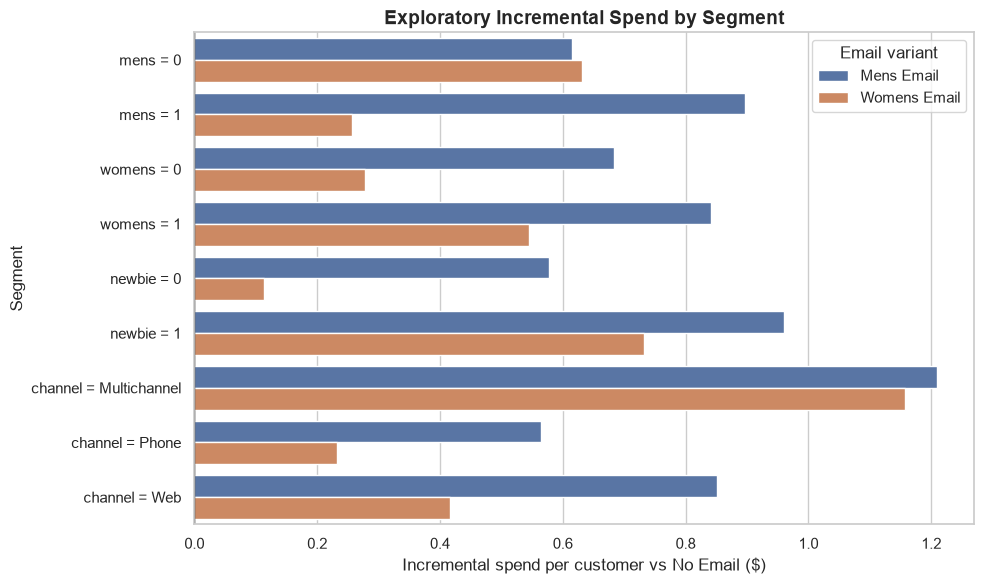

,segment_column,segment_value,customers,control_spend_per_customer,mens_email_spend_per_customer,womens_email_spend_per_customer,mens_incremental_spend,womens_incremental_spend
1,mens,1,35266,$0.78,$1.68,$1.04,$0.90,$0.26
3,womens,1,35182,$0.62,$1.46,$1.16,$0.84,$0.54
5,newbie,1,32144,$0.37,$1.33,$1.10,$0.96,$0.73
4,newbie,0,31856,$0.94,$1.51,$1.05,$0.58,$0.11
2,womens,0,28818,$0.70,$1.38,$0.97,$0.68,$0.28
0,mens,0,28734,$0.49,$1.11,$1.12,$0.62,$0.63
8,channel,Web,28217,$0.67,$1.52,$1.09,$0.85,$0.42
7,channel,Phone,28021,$0.64,$1.21,$0.88,$0.56,$0.23
6,channel,Multichannel,7762,$0.62,$1.82,$1.77,$1.21,$1.16


In [39]:
segment_review_rows = []
segment_columns = ['mens', 'womens', 'newbie', 'channel']

for segment_column in segment_columns:
    for segment_value in sorted(df_clean[segment_column].unique()):
        segment_data = df_clean[df_clean[segment_column].eq(segment_value)]

        control_mean = segment_data.loc[segment_data['segment'].eq('No E-Mail'), 'spend'].mean()
        mens_mean = segment_data.loc[segment_data['segment'].eq('Mens E-Mail'), 'spend'].mean()
        womens_mean = segment_data.loc[segment_data['segment'].eq('Womens E-Mail'), 'spend'].mean()

        segment_review_rows.append({
            'segment_column': segment_column,
            'segment_value': segment_value,
            'customers': len(segment_data),
            'control_spend_per_customer': control_mean,
            'mens_email_spend_per_customer': mens_mean,
            'womens_email_spend_per_customer': womens_mean,
            'mens_incremental_spend': mens_mean - control_mean,
            'womens_incremental_spend': womens_mean - control_mean
        })

segment_review = pd.DataFrame(segment_review_rows)

segment_plot_data = segment_review.melt(
    id_vars=['segment_column', 'segment_value', 'customers'],
    value_vars=['mens_incremental_spend', 'womens_incremental_spend'],
    var_name='email_variant',
    value_name='incremental_spend_per_customer'
)

segment_plot_data['email_variant'] = segment_plot_data['email_variant'].replace({
    'mens_incremental_spend': 'Mens Email',
    'womens_incremental_spend': 'Womens Email'
})
segment_plot_data['segment_label'] = segment_plot_data['segment_column'].astype(str) + ' = ' + segment_plot_data['segment_value'].astype(str)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=segment_plot_data,
    y='segment_label',
    x='incremental_spend_per_customer',
    hue='email_variant'
)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Exploratory Incremental Spend by Segment', fontsize=14, weight='bold')
ax.set_xlabel('Incremental spend per customer vs No Email ($)')
ax.set_ylabel('Segment')
ax.legend(title='Email variant')

plt.tight_layout()
plt.show()

segment_review_display = segment_review.copy()
for column in [
    'control_spend_per_customer',
    'mens_email_spend_per_customer',
    'womens_email_spend_per_customer',
    'mens_incremental_spend',
    'womens_incremental_spend'
]:
    segment_review_display[column] = segment_review_display[column].apply('${:,.2f}'.format)

segment_review_display.sort_values('customers', ascending=False)

The table above suggests that email lift is not identical across customer groups. Mens Email looks especially strong among prior mens buyers, new customers, and multichannel customers. Womens Email appears more competitive among customers with prior womens purchases and multichannel customers. These are good follow-up targeting ideas for future projects.

# 8. Conclusion and Final Recommendation

The A/B test results indicate that promotional email increased spend per customer compared with the no-email control group. Both Mens Email and Womens Email generated positive incremental spend per customer, suggesting that email outreach was effective at encouraging customers to return to the website and make purchases.

Mens Email is the stronger candidate for broader rollout. It produced the highest spend per customer, visit rate, and conversion rate, making it the best-performing campaign overall. Compared with No Email, Mens Email added an estimated $0.77 in spend per customer, while Womens Email added $0.42 per customer. Mens Email also outperformed Womens Email by approximately $0.35 in incremental spend per customer, which makes it a reasonable benchmark creative for the next campaign test.

From a business perspective, the email campaign appears to work by increasing both site engagement and purchase conversion. The improved visit and conversion rates suggest that email reminders or promotions successfully brought more customers back to the site and encouraged more transactions. Spend per buyer did not show an obvious quality concern, which suggests the lift was not simply driven by lower-value purchases.

There are several limitations to consider before making a full production decision. The dataset does not include email opens, click-through rates, unsubscribes, spam complaints, profit margin, or long-term customer value. These missing guardrails matter because a campaign that increases short-term revenue could still harm customer experience or profitability if it causes unsubscribes, low-margin purchases, or weak long-term retention.

The recommended next step is to run a follow-up email test that personalizes product-category messaging based on prior purchase behavior. This test should use Mens Email as the benchmark creative, compare it against more targeted product-category variants, and track customer-experience and profitability guardrails such as unsubscribe rate, complaint rate, gross margin, and repeat purchase behavior.